# Data-driven neural network vs PINN for the diffusion equation

This notebook walks through a small but powerful example:

1. We generate synthetic data from the 1D diffusion equation.
2. We train a purely data-driven neural network using only sparse observations.
3. We show that the data-only model may fit the observed data but can violate the physics.
4. We train a physics-informed neural network (PINN) by adding the diffusion equation as a loss term.
5. We compare the two models using plots and physical diagnostics.

The governing equation is

$$
u_t = \alpha u_{xx}
$$

where $u(t,x)$ could represent temperature, concentration, or density, and $\alpha$ is the diffusion coefficient.

The key idea is simple:

- A data-only neural network learns from examples.
- A PINN learns from examples **and** from the governing equation.

## 1. Imports and setup

We use PyTorch for the neural networks and automatic differentiation.  
The notebook should run on CPU, but it will use CUDA automatically if available.

In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

print("Using device:", device)

/home/patrick/miniconda3/envs/comp_optics/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Define the physical problem

We use a Gaussian pulse as the initial condition. For the diffusion equation on an infinite domain, the exact solution remains Gaussian but gets wider and lower over time:

$$
u(x,t)
=
\frac{\sigma}{\sqrt{\sigma^2 + 2\alpha t}}
\exp\left(
-\frac{(x-\mu)^2}{2(\sigma^2 + 2\alpha t)}
\right).
$$

This solution satisfies

$$
u_t - \alpha u_{xx} = 0.
$$

We evaluate it on the finite domain

$$
x \in [0,1], \quad t \in [0,1].
$$

The Gaussian is centered at $x=0.5$, so the boundary values near $x=0$ and $x=1$ are small.

In [3]:
# Physical parameters
alpha = 0.02   # diffusion coefficient
mu = 0.5       # center of the Gaussian
sigma = 0.08   # initial width

# Domain
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

def true_solution(t, x, alpha=alpha, mu=mu, sigma=sigma):
    """
    Exact Gaussian solution of the 1D diffusion equation on an infinite domain.

    Inputs:
        t, x: torch tensors with the same shape
    Output:
        u(t,x)
    """
    var = sigma**2 + 2.0 * alpha * t
    amplitude = sigma / torch.sqrt(var)
    exponent = -((x - mu)**2) / (2.0 * var)
    return amplitude * torch.exp(exponent)

## 3. Visualize the ground-truth diffusion process

The pulse should smoothly spread out and decrease in height.  
This is the physical behavior we want the models to learn.

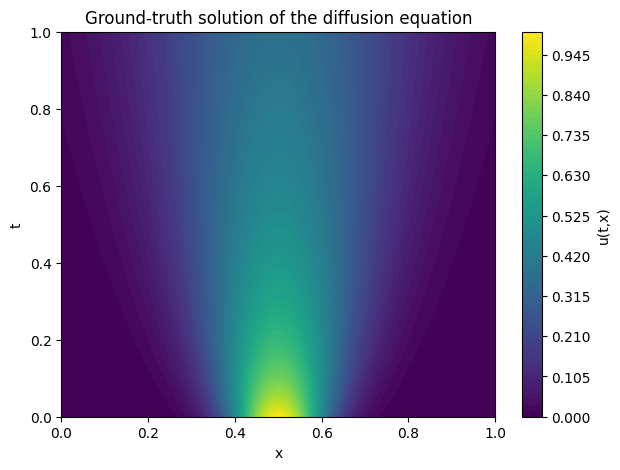

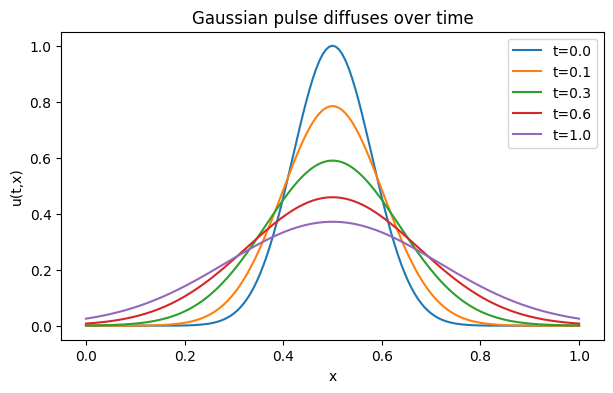

In [4]:
# Create a full evaluation grid
Nx = 151
Nt = 151

x = torch.linspace(x_min, x_max, Nx, device=device, dtype=dtype)
t = torch.linspace(t_min, t_max, Nt, device=device, dtype=dtype)

T, X = torch.meshgrid(t, x, indexing="ij")
U_true = true_solution(T, X)

# Move to NumPy for plotting
T_np = T.detach().cpu().numpy()
X_np = X.detach().cpu().numpy()
U_true_np = U_true.detach().cpu().numpy()

plt.figure(figsize=(7, 5))
plt.contourf(X_np, T_np, U_true_np, levels=80)
plt.colorbar(label="u(t,x)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Ground-truth solution of the diffusion equation")
plt.show()

plt.figure(figsize=(7, 4))
for time_value in [0.0, 0.1, 0.3, 0.6, 1.0]:
    t_line = torch.full_like(x, time_value)
    u_line = true_solution(t_line, x).detach().cpu().numpy()
    plt.plot(x.detach().cpu().numpy(), u_line, label=f"t={time_value}")
plt.xlabel("x")
plt.ylabel("u(t,x)")
plt.title("Gaussian pulse diffuses over time")
plt.legend()
plt.show()

## 4. Create sparse and biased training data

Now we intentionally create a difficult learning situation.

The data-only neural network will only see a small number of noisy observations, mostly from early times.  
This is where a pure data fit can look reasonable at the observed points but become physically questionable elsewhere.

The PINN will see the same sparse data, but it will also be constrained by:

- the initial condition,
- the boundary condition,
- the PDE residual $$u_t - \alpha u_{xx}$$

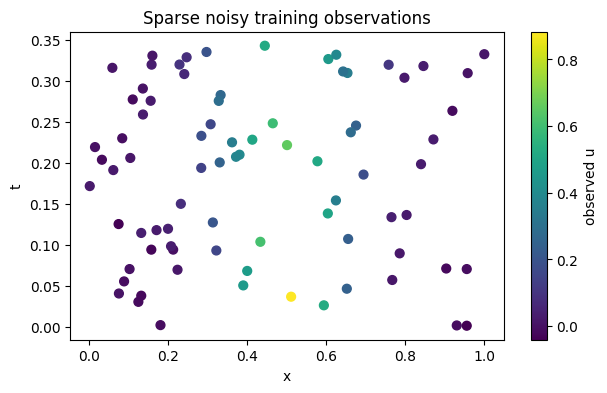

In [5]:
# Number of sparse observations for the data loss
n_data = 80

# Biased data: mostly early times, not the full time interval
t_data = 0.35 * torch.rand(n_data, 1, device=device, dtype=dtype)
x_data = torch.rand(n_data, 1, device=device, dtype=dtype)

u_data_clean = true_solution(t_data, x_data)

# Add small measurement noise to make the pure data-driven task less ideal
noise_level = 0.02
u_data = u_data_clean + noise_level * torch.randn_like(u_data_clean)

# Network inputs are pairs (t, x)
tx_data = torch.cat([t_data, x_data], dim=1)

plt.figure(figsize=(7, 4))
plt.scatter(
    x_data.detach().cpu().numpy(),
    t_data.detach().cpu().numpy(),
    c=u_data.detach().cpu().numpy().ravel(),
    s=40,
)
plt.colorbar(label="observed u")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Sparse noisy training observations")
plt.show()

## 5. Define a simple neural network

Both models use the same architecture.

The input is

$$
(t,x)
$$

and the output is

$$
u_\theta(t,x).
$$

The difference is not the architecture.  
The difference is the loss function.

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=64, out_dim=1, depth=4):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(depth - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, tx):
        return self.net(tx)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


test_model = MLP().to(device)
print("Number of trainable parameters:", count_parameters(test_model))

Number of trainable parameters: 12737


## 6. Train a purely data-driven neural network

The data-only model minimizes only

$$
\mathcal{L}_{data}
=
\frac{1}{N}
\sum_i
\left(
u_\theta(t_i,x_i) - u_i
\right)^2.
$$

It has no knowledge of the diffusion equation.

This is intentionally unfair from a physics point of view.  
The purpose is to show that fitting sparse data does not guarantee physical consistency.

Training data-only NN: 100%|██████████| 4000/4000 [00:07<00:00, 502.79it/s]


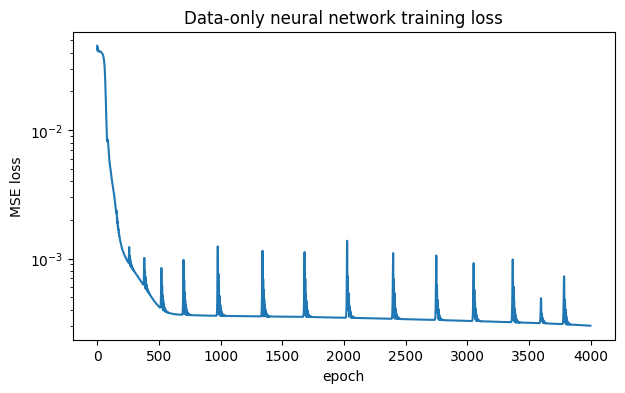

In [7]:
data_model = MLP(hidden_dim=64, depth=4).to(device)
optimizer = torch.optim.Adam(data_model.parameters(), lr=1e-3)

n_epochs_data = 4000
data_loss_history = []

for epoch in tqdm(range(n_epochs_data), desc="Training data-only NN"):
    optimizer.zero_grad()
    pred = data_model(tx_data)
    loss = F.mse_loss(pred, u_data)
    loss.backward()
    optimizer.step()

    data_loss_history.append(loss.item())

plt.figure(figsize=(7, 4))
plt.semilogy(data_loss_history)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Data-only neural network training loss")
plt.show()

## 7. Define the PDE residual for the PINN

For a PINN, we need the residual

$$
r_\theta(t,x)
=
u_t - \alpha u_{xx}.
$$

PyTorch autograd lets us compute $u_t$ and $u_{xx}$ automatically.

In [8]:
def diffusion_residual(model, tx, alpha=alpha):
    """
    Compute r = u_t - alpha * u_xx using automatic differentiation.

    tx has shape (N, 2), where columns are [t, x].
    """
    tx = tx.clone().detach().requires_grad_(True)
    u = model(tx)

    # First derivatives: du/dt and du/dx
    grad_u = torch.autograd.grad(
        outputs=u,
        inputs=tx,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]

    u_t = grad_u[:, 0:1]
    u_x = grad_u[:, 1:2]

    # Second derivative: d2u/dx2
    grad_u_x = torch.autograd.grad(
        outputs=u_x,
        inputs=tx,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True,
    )[0]

    u_xx = grad_u_x[:, 1:2]

    residual = u_t - alpha * u_xx
    return residual

## 8. Create PINN training points

The PINN uses four types of points:

1. Sparse data points  
2. Initial condition points at \(t=0\)  
3. Boundary condition points at \(x=0\) and \(x=1\)  
4. Interior collocation points for the PDE residual  

The important part is that the PDE residual is evaluated at many interior points where no data are observed.

In [9]:
# Initial condition points
n_ic = 128
x_ic = torch.linspace(x_min, x_max, n_ic, device=device, dtype=dtype).reshape(-1, 1)
t_ic = torch.zeros_like(x_ic)
tx_ic = torch.cat([t_ic, x_ic], dim=1)
u_ic = true_solution(t_ic, x_ic)

# Boundary condition points
n_bc = 128
t_bc = torch.linspace(t_min, t_max, n_bc, device=device, dtype=dtype).reshape(-1, 1)

x_left = torch.full_like(t_bc, x_min)
x_right = torch.full_like(t_bc, x_max)

tx_bc_left = torch.cat([t_bc, x_left], dim=1)
tx_bc_right = torch.cat([t_bc, x_right], dim=1)
tx_bc = torch.cat([tx_bc_left, tx_bc_right], dim=0)

u_bc_left = true_solution(t_bc, x_left)
u_bc_right = true_solution(t_bc, x_right)
u_bc = torch.cat([u_bc_left, u_bc_right], dim=0)

# PDE collocation points
n_pde = 2000
t_pde = torch.rand(n_pde, 1, device=device, dtype=dtype)
x_pde = torch.rand(n_pde, 1, device=device, dtype=dtype)
tx_pde = torch.cat([t_pde, x_pde], dim=1)

print("Data points:", tx_data.shape)
print("Initial condition points:", tx_ic.shape)
print("Boundary condition points:", tx_bc.shape)
print("PDE collocation points:", tx_pde.shape)

Data points: torch.Size([80, 2])
Initial condition points: torch.Size([128, 2])
Boundary condition points: torch.Size([256, 2])
PDE collocation points: torch.Size([2000, 2])


## 9. Train the PINN

The PINN minimizes a combined loss:

$$
\mathcal{L}
=
\lambda_{data}\mathcal{L}_{data}
+
\lambda_{IC}\mathcal{L}_{IC}
+
\lambda_{BC}\mathcal{L}_{BC}
+
\lambda_{PDE}\mathcal{L}_{PDE}.
$$

where

$$
\mathcal{L}_{PDE}
=
\frac{1}{N}
\sum_j
\left(
u_t(t_j,x_j) - \alpha u_{xx}(t_j,x_j)
\right)^2.
$$

The PINN is still a neural network, but the training objective now encodes the physics.

Training PINN: 100%|██████████| 4000/4000 [01:02<00:00, 64.06it/s]


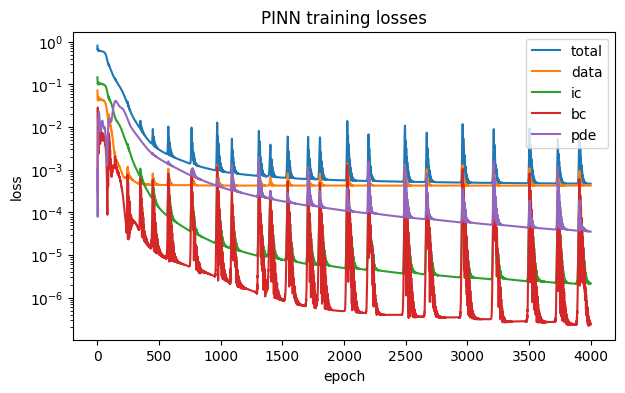

In [10]:
pinn_model = MLP(hidden_dim=64, depth=4).to(device)
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=1e-3)

# Loss weights
lambda_data = 1.0
lambda_ic = 5.0
lambda_bc = 5.0
lambda_pde = 1.0

n_epochs_pinn = 4000

history = {
    "total": [],
    "data": [],
    "ic": [],
    "bc": [],
    "pde": [],
}

for epoch in tqdm(range(n_epochs_pinn), desc="Training PINN"):
    optimizer.zero_grad()

    # Data loss
    pred_data = pinn_model(tx_data)
    loss_data = F.mse_loss(pred_data, u_data)

    # Initial condition loss
    pred_ic = pinn_model(tx_ic)
    loss_ic = F.mse_loss(pred_ic, u_ic)

    # Boundary condition loss
    pred_bc = pinn_model(tx_bc)
    loss_bc = F.mse_loss(pred_bc, u_bc)

    # PDE residual loss
    residual = diffusion_residual(pinn_model, tx_pde, alpha=alpha)
    loss_pde = torch.mean(residual**2)

    loss = (
        lambda_data * loss_data
        + lambda_ic * loss_ic
        + lambda_bc * loss_bc
        + lambda_pde * loss_pde
    )

    loss.backward()
    optimizer.step()

    history["total"].append(loss.item())
    history["data"].append(loss_data.item())
    history["ic"].append(loss_ic.item())
    history["bc"].append(loss_bc.item())
    history["pde"].append(loss_pde.item())

plt.figure(figsize=(7, 4))
for key, values in history.items():
    plt.semilogy(values, label=key)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("PINN training losses")
plt.legend()
plt.show()

## 10. Evaluate both models on the full space-time grid

Now we compare the predictions everywhere, not only at the sparse training points.

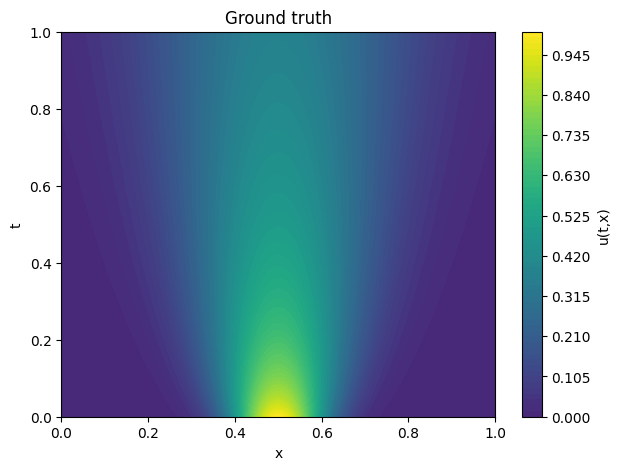

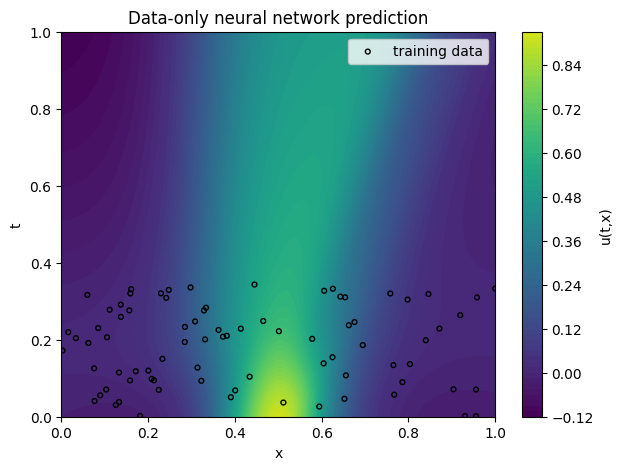

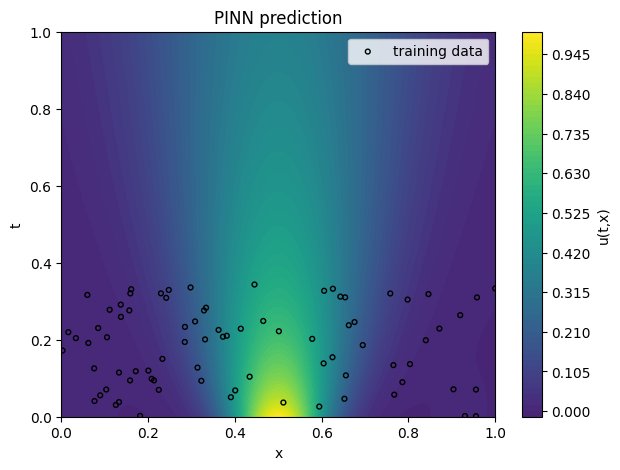

In [11]:
# Flatten full grid into model input format
tx_grid = torch.cat([T.reshape(-1, 1), X.reshape(-1, 1)], dim=1)

with torch.no_grad():
    U_data_pred = data_model(tx_grid).reshape(Nt, Nx)
    U_pinn_pred = pinn_model(tx_grid).reshape(Nt, Nx)

U_data_np = U_data_pred.detach().cpu().numpy()
U_pinn_np = U_pinn_pred.detach().cpu().numpy()

vmin = min(U_true_np.min(), U_data_np.min(), U_pinn_np.min())
vmax = max(U_true_np.max(), U_data_np.max(), U_pinn_np.max())

plt.figure(figsize=(7, 5))
plt.contourf(X_np, T_np, U_true_np, levels=80, vmin=vmin, vmax=vmax)
plt.colorbar(label="u(t,x)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Ground truth")
plt.show()

plt.figure(figsize=(7, 5))
plt.contourf(X_np, T_np, U_data_np, levels=80, vmin=vmin, vmax=vmax)
plt.colorbar(label="u(t,x)")
plt.scatter(
    x_data.detach().cpu().numpy(),
    t_data.detach().cpu().numpy(),
    s=12,
    edgecolor="k",
    facecolor="none",
    label="training data",
)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Data-only neural network prediction")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.contourf(X_np, T_np, U_pinn_np, levels=80, vmin=vmin, vmax=vmax)
plt.colorbar(label="u(t,x)")
plt.scatter(
    x_data.detach().cpu().numpy(),
    t_data.detach().cpu().numpy(),
    s=12,
    edgecolor="k",
    facecolor="none",
    label="training data",
)
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN prediction")
plt.legend()
plt.show()

## 11. Compare line plots at several times

A good diffusion solution should become smoother and lower over time.

This line plot often makes the difference between the models easier to see than the contour plot.

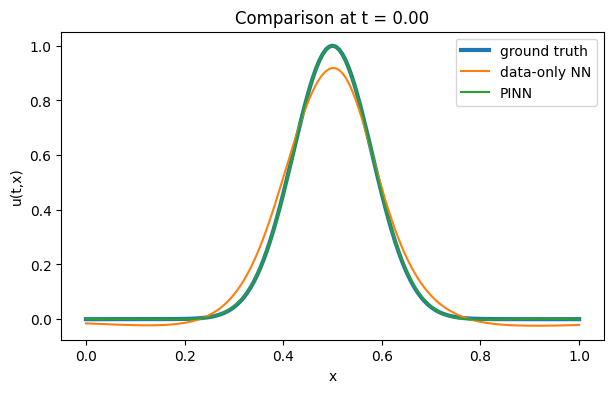

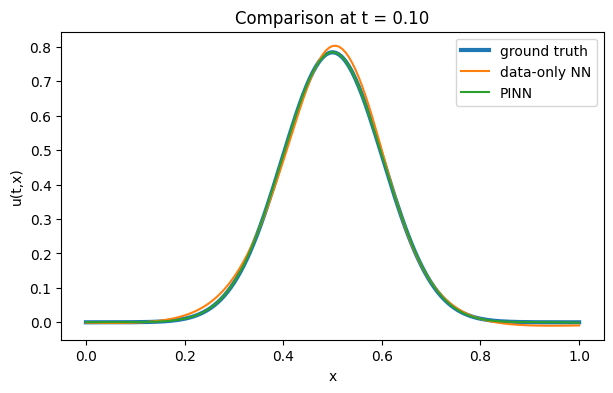

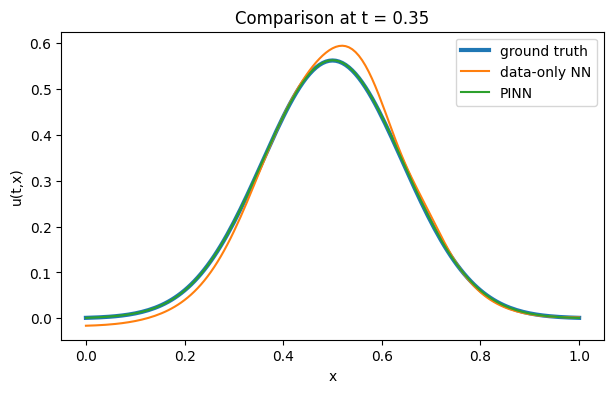

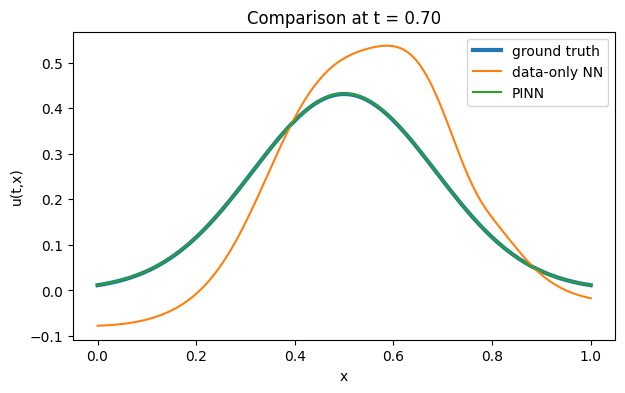

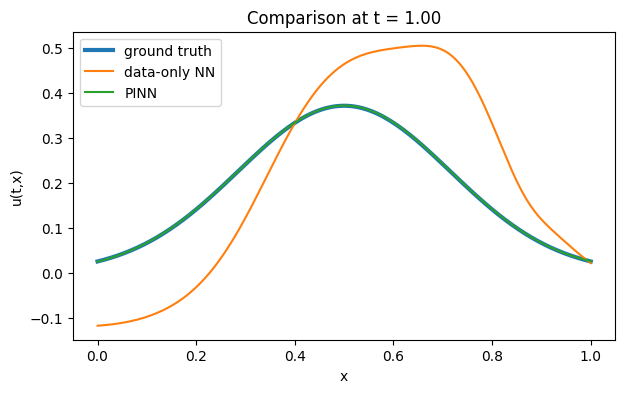

In [12]:
x_cpu = x.detach().cpu().numpy()
times_to_plot = [0.0, 0.1, 0.35, 0.7, 1.0]

for time_value in times_to_plot:
    idx = int(round(time_value * (Nt - 1) / t_max))

    plt.figure(figsize=(7, 4))
    plt.plot(x_cpu, U_true_np[idx], label="ground truth", linewidth=3)
    plt.plot(x_cpu, U_data_np[idx], label="data-only NN")
    plt.plot(x_cpu, U_pinn_np[idx], label="PINN")
    plt.xlabel("x")
    plt.ylabel("u(t,x)")
    plt.title(f"Comparison at t = {time_value:.2f}")
    plt.legend()
    plt.show()

## 12. Physical diagnostics

A model can have small error at observed points while still violating the physics.

We compare:

1. MSE on the full grid  
2. PDE residual MSE  
3. Minimum predicted value  
4. Peak height over time  

For this problem, strong negative values and increasing peaks are suspicious because diffusion should smooth and spread the pulse.

data_only_full_grid_mse         : 6.321406e-03
pinn_full_grid_mse              : 4.183123e-07
data_only_pde_residual_mse      : 1.017886e-01
pinn_pde_residual_mse           : 3.838631e-05
data_only_min_value             : -1.178507e-01
pinn_min_value                  : -1.762785e-03
ground_truth_min_value          : 3.293714e-09


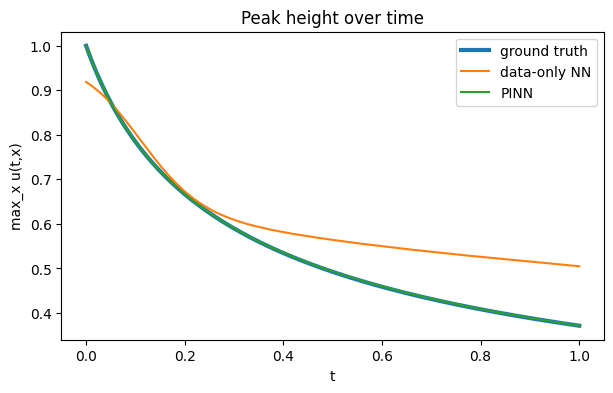

In [13]:
def mse_full_grid(U_pred, U_true):
    return torch.mean((U_pred - U_true)**2).item()

def pde_residual_mse(model, n_eval=5000):
    t_eval = torch.rand(n_eval, 1, device=device, dtype=dtype)
    x_eval = torch.rand(n_eval, 1, device=device, dtype=dtype)
    tx_eval = torch.cat([t_eval, x_eval], dim=1)
    residual = diffusion_residual(model, tx_eval, alpha=alpha)
    return torch.mean(residual**2).item()

def peak_over_time(U):
    return U.max(dim=1).values.detach().cpu().numpy()

metrics = {
    "data_only_full_grid_mse": mse_full_grid(U_data_pred, U_true),
    "pinn_full_grid_mse": mse_full_grid(U_pinn_pred, U_true),
    "data_only_pde_residual_mse": pde_residual_mse(data_model),
    "pinn_pde_residual_mse": pde_residual_mse(pinn_model),
    "data_only_min_value": U_data_pred.min().item(),
    "pinn_min_value": U_pinn_pred.min().item(),
    "ground_truth_min_value": U_true.min().item(),
}

for key, value in metrics.items():
    print(f"{key:32s}: {value:.6e}")

plt.figure(figsize=(7, 4))
plt.plot(t.detach().cpu().numpy(), peak_over_time(U_true), label="ground truth", linewidth=3)
plt.plot(t.detach().cpu().numpy(), peak_over_time(U_data_pred), label="data-only NN")
plt.plot(t.detach().cpu().numpy(), peak_over_time(U_pinn_pred), label="PINN")
plt.xlabel("t")
plt.ylabel("max_x u(t,x)")
plt.title("Peak height over time")
plt.legend()
plt.show()

## 13. Visualize the PDE residual

The most direct way to see physical consistency is to plot

$$
|u_t - \alpha u_{xx}|.
$$

A physically feasible solution should have a small residual across the domain.

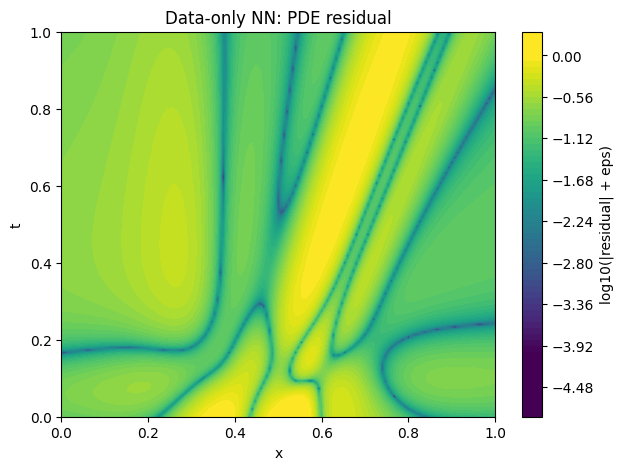

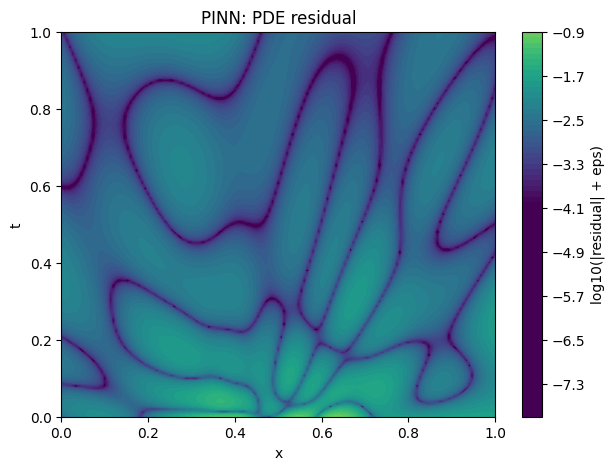

In [15]:
all_log_residuals = np.concatenate([
    log_R_data.ravel(),
    log_R_pinn.ravel()
])

vmin = np.percentile(all_log_residuals, 1)
vmax = np.percentile(all_log_residuals, 99)

plt.figure(figsize=(7, 5))
plt.contourf(X_np, T_np, log_R_data, levels=80, vmin=vmin, vmax=vmax)
plt.colorbar(label="log10(|residual| + eps)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Data-only NN: PDE residual")
plt.show()

plt.figure(figsize=(7, 5))
plt.contourf(X_np, T_np, log_R_pinn, levels=80, vmin=vmin, vmax=vmax)
plt.colorbar(label="log10(|residual| + eps)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN: PDE residual")
plt.show()

## 14. Interpretation

The data-only neural network is trained only to match sparse noisy observations.  
It may interpolate the available data, but it has no reason to satisfy

$$
u_t = \alpha u_{xx}.
$$

Therefore, it can produce predictions that look plausible near the observed points but are physically inconsistent elsewhere.

The PINN uses the same sparse data, but it also receives physical guidance from the PDE residual, initial condition, and boundary condition.  
As a result, it is encouraged to find a function that is not only close to the observations but also physically feasible across the full space-time domain.

This is the central motivation behind physics-informed machine learning:

$$
\text{data fit} + \text{physical law} \rightarrow \text{more physically meaningful predictions}.
$$

## 15. Optional experiments

Try changing these settings:

- Reduce `n_data` from 80 to 30.
- Increase `noise_level` from 0.02 to 0.05.
- Train only on very early times by changing `0.35 * torch.rand(...)` to `0.15 * torch.rand(...)`.
- Increase or decrease `lambda_pde`.
- Increase the number of PDE collocation points `n_pde`.

Typical behavior:

- Less data makes the data-only model less reliable.
- A larger PDE loss usually improves physical consistency.
- Too large a PDE loss may ignore noisy data too strongly.
- The PINN usually has a much smaller PDE residual than the data-only model.